In [33]:
import numpy as np

from EventStreamGenerator import EventTimestampGenerator, EventSampleSpace, EventStreamGenerator

In [34]:
import logging

logger = logging.getLogger(__name__)

# Configure root logger once:
logging.basicConfig(
    level=logging.DEBUG,                            # show DEBUG+ messages
    format="%(asctime)s %(name)s %(levelname)s: %(message)s",
)

In [35]:
N = 3
cycles = 1
time_intervals_1 = [(i, i+1) for i in range(N)]
occurrences_1 = [i+1 for i in range(N)]
noise_sds_1 = [0]*N
no_occurrences_sds_1 = [0]*N


time_intervals_2 = [(i, i+1) for i in range(N)]
occurrences_2 = [N-i for i in range(N)]
noise_sds_2 = [0.3]*N
no_occurrences_sds_2 = [0]*N

print("Time intervals:", time_intervals_1)
print("Occurrences:", occurrences_1)
print("Period standard deviations:", noise_sds_1)
print("Number of occurrences standard deviations:", no_occurrences_sds_1)
print("Time intervals 2:", time_intervals_2)
print("Occurrences 2:", occurrences_2)
print("Period standard deviations 2:", noise_sds_2)
print("Number of occurrences standard deviations 2:", no_occurrences_sds_2)

Time intervals: [(0, 1), (1, 2), (2, 3)]
Occurrences: [1, 2, 3]
Period standard deviations: [0, 0, 0]
Number of occurrences standard deviations: [0, 0, 0]
Time intervals 2: [(0, 1), (1, 2), (2, 3)]
Occurrences 2: [3, 2, 1]
Period standard deviations 2: [0.3, 0.3, 0.3]
Number of occurrences standard deviations 2: [0, 0, 0]


In [36]:
class ExampleETG(EventTimestampGenerator):
    """Class representing the frequency of events over time, defined by occurrences and time intervals"""
    def __init__(self, occurrences, time_intervals, noise_sds, occurrences_sds):
        self.noise_sds = noise_sds
        self.occurrences_sds = occurrences_sds
        super().__init__(occurrences, time_intervals)
        
        
    def sample_noise (self, i):
        """Samples a timing interval"""
        return np.random.normal(loc=0, scale=self.noise_sds[i])
    
    def sample_occurrences(self, occurrences_i, i):
        sample = int(np.round(np.random.normal(loc=occurrences_i, scale=self.occurrences_sds[i])))
        return sample


class ExampleSampleSpace(EventSampleSpace):
    def __init__(self, default_value=1):
        super().__init__()
        self.default_value = default_value
    
    def sample(self, t):
        sample = np.random.normal(loc=self.default_value, scale=0)
        return .5 if sample <= .5 else sample

In [37]:
etg_1 = ExampleETG(occurrences_1, time_intervals_1, noise_sds_1, no_occurrences_sds_1)
ess_1 = ExampleSampleSpace(default_value=.5)

etg_2 = ExampleETG(occurrences_2, time_intervals_2, noise_sds_2, no_occurrences_sds_2)
ess_2 = ExampleSampleSpace(default_value=1)

2025-08-01 12:56:43,613 utils DEBUG: Checks if constraint is satisfied with value: 1
2025-08-01 12:56:43,613 utils DEBUG: Constraint satisfied
2025-08-01 12:56:43,614 utils DEBUG: Checks if constraint is satisfied with value: 2
2025-08-01 12:56:43,614 utils DEBUG: Constraint satisfied
2025-08-01 12:56:43,614 utils DEBUG: Checks if constraint is satisfied with value: 3
2025-08-01 12:56:43,615 utils DEBUG: Constraint satisfied
2025-08-01 12:56:43,615 EventStreamGenerator DEBUG: new occurrences: [1, 2, 3]
2025-08-01 12:56:43,615 EventStreamGenerator DEBUG: new spacings: [0.5, 0.3333333333333333, 0.25]
2025-08-01 12:56:43,615 utils DEBUG: Checks if constraint is satisfied with value: 3
2025-08-01 12:56:43,616 utils DEBUG: Constraint satisfied
2025-08-01 12:56:43,616 utils DEBUG: Checks if constraint is satisfied with value: 2
2025-08-01 12:56:43,616 utils DEBUG: Constraint satisfied
2025-08-01 12:56:43,616 utils DEBUG: Checks if constraint is satisfied with value: 1
2025-08-01 12:56:43,616

In [38]:
def on_event(event):
    logger.info(f"event: {event}")
    logger.info("--------")

time_series_generator = EventStreamGenerator([(etg_1, ess_1), (etg_2, ess_2)], on_event)
data = time_series_generator.run(cycles*N, 100)
logger.info(f"Generated data: {data}")

2025-08-01 12:56:43,623 utils DEBUG: Checks if constraint is satisfied with value: 0.18491489641139547
2025-08-01 12:56:43,623 utils DEBUG: Constraint satisfied
2025-08-01 12:56:43,624 utils DEBUG: Checks if constraint is satisfied with value: 0.5
2025-08-01 12:56:43,624 utils DEBUG: Constraint satisfied
2025-08-01 12:56:43,624 EventStreamGenerator DEBUG: Waiting 0.18477184526393453 seconds.
2025-08-01 12:56:43,626 utils DEBUG: Checks if constraint is satisfied with value: 1.0
2025-08-01 12:56:43,627 utils DEBUG: Constraint satisfied
2025-08-01 12:56:43,627 __main__ INFO: event: (0.18491489641139547, 1.0)
2025-08-01 12:56:43,628 __main__ INFO: --------
2025-08-01 12:56:43,628 utils DEBUG: Checks if constraint is satisfied with value: 0.8020080849981515
2025-08-01 12:56:43,628 utils DEBUG: Constraint satisfied
2025-08-01 12:56:43,629 EventStreamGenerator DEBUG: Waiting 0.08109855651855469 seconds.
2025-08-01 12:56:43,629 utils DEBUG: Checks if constraint is satisfied with value: 0.5
202

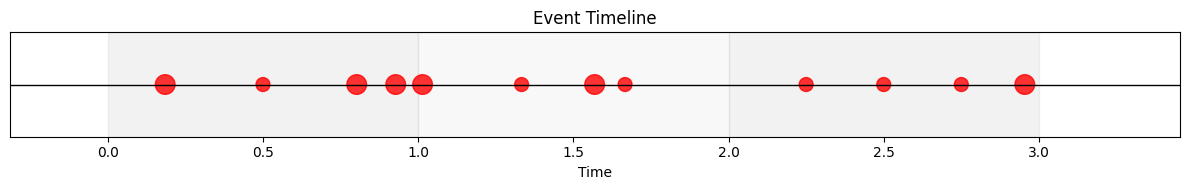

In [39]:
from Analytics import plot_timeline, extend_intervals
plot_timeline(data, extend_intervals(time_intervals_1, cycles))


In [40]:
from Analytics import count_number_of_occurrences_in_intervals
count_number_of_occurrences_in_intervals(extend_intervals(time_intervals_1, cycles), data)

[4, 4, 4]